In [173]:
#all imports:
import astropy
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt
import math
from astroquery.mast import Observations, Mast, MastMissions
from astroquery.simbad import Simbad
import pandas as pd
import numpy as np
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.coordinates import search_around_sky

In [174]:
#initialitze variables:
k2_table = '/home/gleb/Astronomy/K2_planet_list.csv'
kepler_table = '/home/gleb/Astronomy/Kepler_planet_list.csv'

In [175]:
k2 = pd.read_csv(k2_table)
kepler = pd.read_csv(kepler_table)
defFlag_mask = k2['default_flag']==1
dispTrue_mask = k2['disposition']=='CONFIRMED'
dispFalse_mask = k2['disposition']=='FALSE POSITIVE'
koiDisp_True_mask = kepler['koi_disposition']=='CONFIRMED'
koiDisp_False_mask = kepler['koi_disposition']=='FALSE POSITIVE'

In [176]:
allspec = Observations.query_criteria(dataproduct_type = 'spectrum', provenance_name = 'apogee', target_classification = 'STAR')

In [177]:
k2_targets_negative = k2[defFlag_mask][dispFalse_mask]

/tmp/ipykernel_102755/240419272.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  k2_targets_negative = k2[defFlag_mask][dispFalse_mask]


In [178]:
allspec_coords = [[],[]]
allspec_coords = [[allspec['s_ra']],[allspec['s_dec']]]

In [179]:
k2_pos_coords = [[k2_targets_negative['ra']],[k2_targets_negative['dec']]]

In [180]:
ra_catalog = allspec_coords[0]*u.degree
dec_catalog = allspec_coords[1]*u.degree
ra_target = k2_pos_coords[0]*u.degree
dec_target = k2_pos_coords[1]*u.degree

In [181]:
target = SkyCoord(ra_target, dec_target)
catalog = SkyCoord(ra_catalog, dec_catalog)

In [182]:
idx_target, idx_obs, sep, _ = search_around_sky(
    target[0],
    catalog[0],
    2*u.arcsec
)

In [183]:
k2_negative_obsid = [[],[]]
for i in range(len(idx_target)):
    match_index_target = idx_target[i]
    match_index_catalog = idx_obs[i]
    obj = k2_targets_negative['hostname'][match_index_target-1:match_index_target]
    obsid = allspec['obsid'][match_index_catalog-1:match_index_catalog]
    #print(f"Object: {obj}. Observation: {obsid[0]}")
    k2_negative_obsid[0].append(obj)
    k2_negative_obsid[1].append(obsid[0])

In [194]:
target_obsids = []
for i in k2_negative_obsid[1]:
    target_obsids.append(str(i))

In [195]:
target_obsids

['234042396',
 '234086956',
 '234291814',
 '234173118',
 '234319133',
 '234575485',
 '234596448',
 '234625780',
 '234461918',
 '234556360',
 '234069373',
 '234461940',
 '234563849',
 '234556521',
 '234400466',
 '234080064',
 '234458631',
 '233938812',
 '234599213',
 '234559258',
 '234559365',
 '234360290',
 '234403709',
 '234604609',
 '234416993',
 '233764438',
 '234311050',
 '234418847',
 '234588167',
 '234095301',
 '234323576',
 '233861393',
 '234033278',
 '234033297',
 '234271830',
 '234355803',
 '234334627',
 '234029263',
 '234302161',
 '234334766',
 '234101480',
 '234084629',
 '234154370',
 '234130030',
 '234321541',
 '233794972',
 '233846596',
 '234321556',
 '234616220',
 '234085055',
 '234101695',
 '234520069',
 '234283010',
 '233794972',
 '233846596',
 '234321556',
 '234616220',
 '234085055',
 '234101695',
 '234520069',
 '234283010',
 '234084539',
 '234084879',
 '233927191',
 '234170824',
 '234306121',
 '233927050',
 '234248305',
 '233926677',
 '234170607',
 '234305932',
 '2338

In [202]:
len(target_obsids)

90

In [231]:
to_load = Observations.filter_products(Observations.get_product_list(target_obsids), dataproduct_type='spectrum', mrp_only=True)

In [232]:
aspcap_mask=['productSubGroupDescription']=='APSTAR'

In [234]:
to_load

obsID,obs_collection,dataproduct_type,obs_id,description,type,dataURI,productType,productGroupDescription,productSubGroupDescription,productDocumentationURL,project,prvversion,proposal_id,productFilename,size,parent_obsid,dataRights,calib_level,filters
str9,str4,str12,str57,str209,str1,str102,str7,str28,str15,str62,str6,str4,str3,str39,int64,str9,str6,int64,str4
233764438,SDSS,spectrum,sdss_apogee_apo25m_k2_c2_000+16_2m16474450-2010484,"SDSS APOGEE combined, RV-corrected spectrum from all nights of observation for a single star.",S,mast:SDSS/apogee/apo25m/K2_C2_000+16/2M16474450-2010484/apStar-dr17-2M16474450-2010484.fits,SCIENCE,Minimum Recommended Products,APSTAR,https://outerspace.stsci.edu/display/SDSS/APOGEE+Data+Products,APOGEE,dr17,N/A,apStar-dr17-2M16474450-2010484.fits,1045440,233764438,PUBLIC,3,None
233764438,SDSS,spectrum,sdss_apogee_apo25m_k2_c2_000+16_2m16474450-2010484,"SDSS APOGEE post-analysis pipeline (ASPCAP) spectrum. The combined spectrum is pseudo-continuum normalized, and includes the measured parameter estimates and best matching synthetic ASPCAP spectrum.",S,mast:SDSS/apogee/apo25m/K2_C2_000+16/2M16474450-2010484/aspcapStar-dr17-2M16474450-2010484.fits,SCIENCE,Minimum Recommended Products,ASPCAPSTAR,https://outerspace.stsci.edu/display/SDSS/APOGEE+Data+Products,APOGEE,dr17,N/A,aspcapStar-dr17-2M16474450-2010484.fits,247680,233764438,PUBLIC,3,None
233794972,SDSS,spectrum,sdss_apogee_apo25m_180-60_2m02273373-0805436,"SDSS APOGEE combined, RV-corrected spectrum from all nights of observation for a single star.",S,mast:SDSS/apogee/apo25m/180-60/2M02273373-0805436/apStar-dr17-2M02273373-0805436.fits,SCIENCE,Minimum Recommended Products,APSTAR,https://outerspace.stsci.edu/display/SDSS/APOGEE+Data+Products,APOGEE,dr17,N/A,apStar-dr17-2M02273373-0805436.fits,3038400,233794972,PUBLIC,3,None
233794972,SDSS,spectrum,sdss_apogee_apo25m_180-60_2m02273373-0805436,"SDSS APOGEE post-analysis pipeline (ASPCAP) spectrum. The combined spectrum is pseudo-continuum normalized, and includes the measured parameter estimates and best matching synthetic ASPCAP spectrum.",S,mast:SDSS/apogee/apo25m/180-60/2M02273373-0805436/aspcapStar-dr17-2M02273373-0805436.fits,SCIENCE,Minimum Recommended Products,ASPCAPSTAR,https://outerspace.stsci.edu/display/SDSS/APOGEE+Data+Products,APOGEE,dr17,N/A,aspcapStar-dr17-2M02273373-0805436.fits,247680,233794972,PUBLIC,3,None
233842314,SDSS,spectrum,sdss_apogee_apo25m_210+30_2m08384409+1638357,"SDSS APOGEE combined, RV-corrected spectrum from all nights of observation for a single star.",S,mast:SDSS/apogee/apo25m/210+30/2M08384409+1638357/apStar-dr17-2M08384409+1638357.fits,SCIENCE,Minimum Recommended Products,APSTAR,https://outerspace.stsci.edu/display/SDSS/APOGEE+Data+Products,APOGEE,dr17,N/A,apStar-dr17-2M08384409+1638357.fits,2548800,233842314,PUBLIC,3,None
233842314,SDSS,spectrum,sdss_apogee_apo25m_210+30_2m08384409+1638357,"SDSS APOGEE post-analysis pipeline (ASPCAP) spectrum. The combined spectrum is pseudo-continuum normalized, and includes the measured parameter estimates and best matching synthetic ASPCAP spectrum.",S,mast:SDSS/apogee/apo25m/210+30/2M08384409+1638357/aspcapStar-dr17-2M08384409+1638357.fits,SCIENCE,Minimum Recommended Products,ASPCAPSTAR,https://outerspace.stsci.edu/display/SDSS/APOGEE+Data+Products,APOGEE,dr17,N/A,aspcapStar-dr17-2M08384409+1638357.fits,247680,233842314,PUBLIC,3,None
233846596,SDSS,spectrum,sdss_apogee_apo25m_m67-rv_2m08474967+1209048,"SDSS APOGEE combined, RV-corrected spectrum from all nights of observation for a single star.",S,mast:SDSS/apogee/apo25m/M67-RV/2M08474967+1209048/apStar-dr17-2M08474967+1209048.fits,SCIENCE,Minimum Recommended Products,APSTAR,https://outerspace.stsci.edu/display/SDSS/APOGEE+Data+Products,APOGEE,dr17,N/A,apStar-dr17-2M08474967+1209048.fits,4567680,233846596,PUBLIC,3,None
233846596,SDSS,spectrum,sdss_apogee_apo25m_m67-rv_2m08474967+1209048,"SDSS APOGEE post-analysis pipeline (ASPCAP) spectrum. The combined spectrum is pseudo

In [146]:
Observations.download_products(to_load, mrp_only=True)

Local Path,Status,Message,URL
str104,str8,object,object
./mastDownload/SDSS/sdss_apogee_apo25m_100+60_2m14065551+5241077/apStar-dr17-2M14065551+5241077.fits,COMPLETE,None,None
./mastDownload/SDSS/sdss_apogee_apo25m_100+60_2m14065551+5241077/aspcapStar-dr17-2M14065551+5241077.fits,COMPLETE,None,None


In [258]:
new_file = 'aspcapStar-dr17-2M14065551+5241077.fits'

In [259]:
data = fits.open(new_file)
flux = data[1].data
apogee_wls = np.logspace(data[1].header['CRVAL1'],
                         data[1].header['CRVAL1']+data[1].header['CDELT1']*data[3].header['NAXIS1'],
                         data[1].header['NAXIS1'])
pixel_mask = (data[2].data < 0.1)

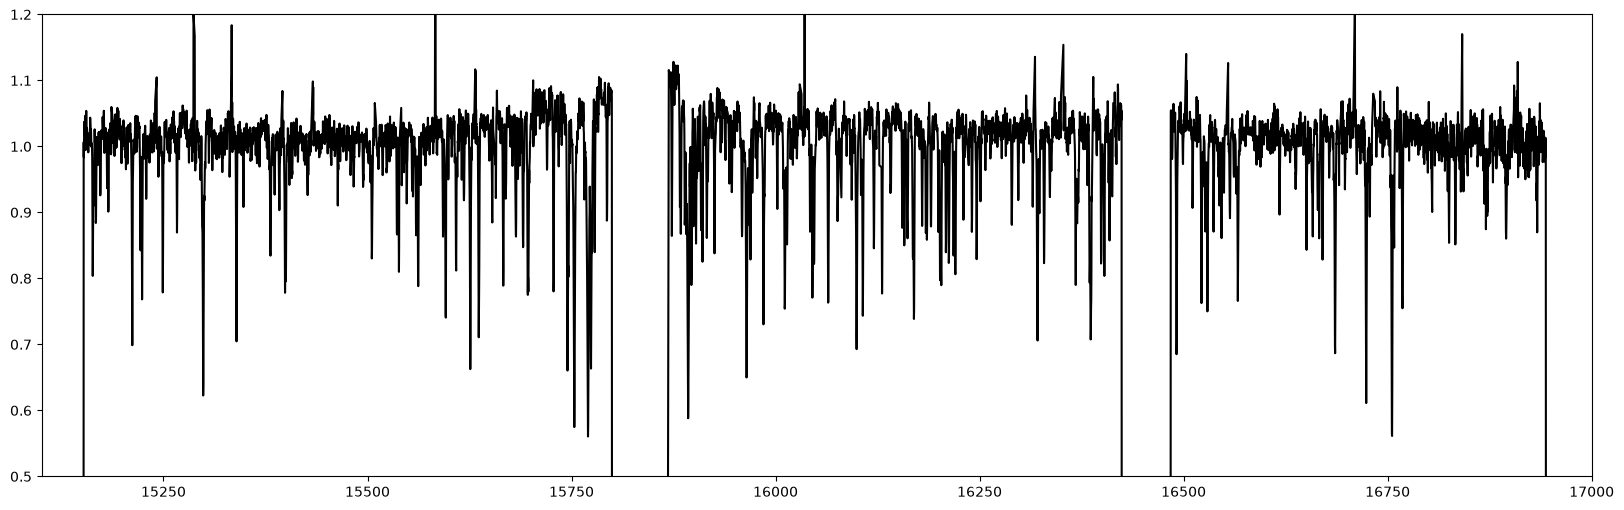

In [260]:
plt.figure(figsize=(20,6))
plt.ylim(0.5, 1.2)
plt.xlim(np.min(apogee_wls[pixel_mask]), np.max(apogee_wls[pixel_mask]))
plt.plot(apogee_wls[pixel_mask], flux[pixel_mask], c='k')